# Chicago Food Inspections: Exploratory Data Analysis

**Dataset:** City of Chicago Food Inspections (July 2018 – March 2026)  
**Records:** ~134,000 inspections across restaurants, childcare facilities, schools, grocery stores, and more.

---

## Objective

The City of Chicago conducts routine food safety inspections across thousands of licensed facilities. This notebook explores the inspection dataset to understand:

- How inspection outcomes (Pass / Fail) are distributed across facility types, inspection types, risk categories, and ZIP codes
- Whether temporal patterns exist in fail rates across months and years
- Which variables show meaningful signal for predicting inspection failure

Findings from this EDA directly inform feature selection and engineering in the companion modeling notebook (`food_modeling.ipynb`).

---

In [19]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/Advanced BA/Datasets')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
food = pd.read_csv('food.csv')
food.head(2)

In [22]:
food.shape

(133999, 17)

In [ ]:
food.info()

### Nulls / Duplicates

In [24]:
#nulls
food.isnull().sum().sort_values(ascending = False)

,0
Violations,39609
Facility Type,722
Longitude,479
Location,479
Latitude,479
AKA Name,255
City,97
State,45
Risk,29
Zip,10


~39k nulls come from `Violations`, but this is not too concerning for the current analysis because the field is sparse and highly unstructured.

Other null counts are relatively small.







In [25]:
#duplicates
food['Inspection ID'].duplicated().sum()
food.duplicated().sum()

np.int64(0)

### Date Cleaning

In [26]:
food['Inspection Date'] = pd.to_datetime(food['Inspection Date'])
food['Inspection Year'] = food['Inspection Date'].dt.year
food['Inspection Month'] = food['Inspection Date'].dt.month


In [27]:
#unique results / counts
food['Results'].value_counts()

,count
Results,
Pass,57465
Pass w/ Conditions,29196
Fail,25662
Out of Business,10167
No Entry,8412
Not Ready,3065
Business Not Located,32


### Target Setup (Pass/Fail) - Class Distribution

In [28]:
food['Fail'] = (food['Results'] == 'Fail').astype(int)
food['Fail'].value_counts()

,count
Fail,
0,108337
1,25662


In [29]:
#further filtering eligble records (also including 'Pass w/ Conditions)
model_eligible = food[food['Results'].isin(['Pass', 'Pass w/ Conditions', 'Fail'])]
fail_counts = model_eligible['Fail'].value_counts()
fail_rate = model_eligible['Fail'].mean()

print(f"Modeling-eligible records: {len(model_eligible):,}")
print(f"Fail: {fail_counts[1]:,} ({fail_rate:.1%})")
print(f"Not Fail: {fail_counts[0]:,} ({1 - fail_rate:.1%})")

Modeling-eligible records: 112,323
Fail: 25,662 (22.8%)
Not Fail: 86,661 (77.2%)


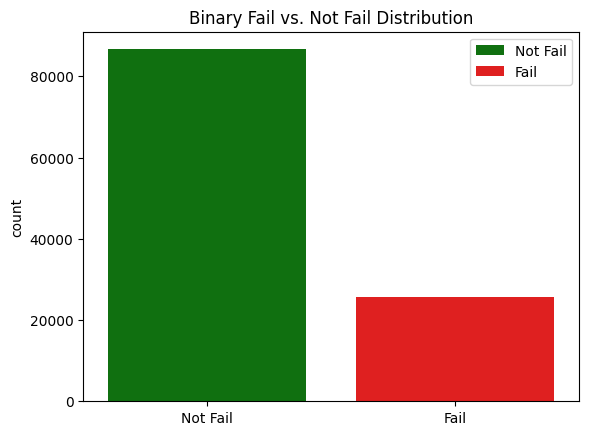

In [30]:
ax = sns.countplot(data = model_eligible, x = 'Fail', hue = 'Fail', palette={0: 'green', 1: 'red'})
plt.xticks([0, 1], ['Not Fail', 'Fail'])
plt.title('Binary Fail vs. Not Fail Distribution')
ax.set_xlabel('')
ax.legend(['Not Fail', 'Fail']);

Of the modeling-eligible records (those that include 'Pass', 'Pass w/ Conditions', and 'Fail'), 25,662 resulted in a failure, leading to a baseline fail rate of 22.8%. This class imbalance is important to note when modeling, as a naive model can just predict the majority class and be deemed highly 'accurate'. This will further justify the use of `class_weight = balanced` as a hyperparameter during modeling setup as to emphasize the importance of the minority (fail) class. Recall on the fail class will be the primary metric during model evaluation.

# **Exploratory Analysis**

### Date Range of Dataset

In [31]:
date_range = max(food['Inspection Date']) - min(food['Inspection Date'])
years = date_range.days / 365
years

7.67945205479452

In [32]:
# exclude incomplete years for temporal charts
food_time_clean = food[~food['Inspection Year'].isin([2018, 2026])]

### Inspections by Year

In [ ]:
inspectionctyr = (
    food_time_clean.groupby(food_time_clean['Inspection Date'].dt.year)
    .size()
    .reset_index(name='Inspection Count')
)


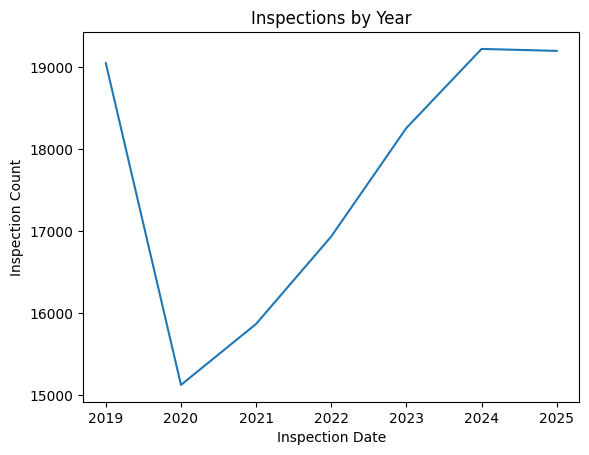

In [34]:
sns.lineplot(data = inspectionctyr,
             x = 'Inspection Date',
             y = 'Inspection Count') #2018 and 2026 - incomplete data

plt.title('Inspections by Year');

Inspection volume dips noticeably from 2020–2022, consistent with COVID-19 disruptions to city operations and facility closures. Volume recovers to pre-pandemic levels by 2023. Years 2018 and 2026 are excluded from temporal charts as they represent incomplete calendar years.

### Common Facility Types

In [35]:
food.groupby('Facility Type').size().sort_values(ascending = False).head(20)

,0
Facility Type,
Restaurant,93136
Grocery Store,14184
School,8320
Children's Services Facility,4705
Daycare Above and Under 2 Years,2075
Bakery,1912
Long Term Care,1273
Daycare (2 - 6 Years),999
Catering,874


Restaurants dominate inspection volume by a wide margin, accounting for the majority of all records. This concentration means model performance will largely reflect restaurant dynamics. Facility type will be grouped into broader categories during feature engineering to reduce dimensionality while preserving meaningful distinctions.

### Result Distribution Between Common Facility Types

In [36]:
food.groupby(['Facility Type',
              'Results']).size().unstack(fill_value = 0).sort_values(by = 'Fail', ascending = False).head(10)

Results,Business Not Located,Fail,No Entry,Not Ready,Out of Business,Pass,Pass w/ Conditions
Facility Type,,,,,,,
Restaurant,8,17313,7227,1971,6994,38152,21471
Grocery Store,2,2979,275,498,1657,5385,3388
School,0,2056,60,10,136,4909,1149
Children's Services Facility,3,765,161,55,188,2772,761
Daycare Above and Under 2 Years,0,423,70,16,80,1149,337
Bakery,1,411,92,65,173,730,440
Long Term Care,0,320,13,7,66,594,273
Daycare (2 - 6 Years),1,176,62,12,71,514,163
Mobile Food Preparer,7,148,10,32,14,363,108


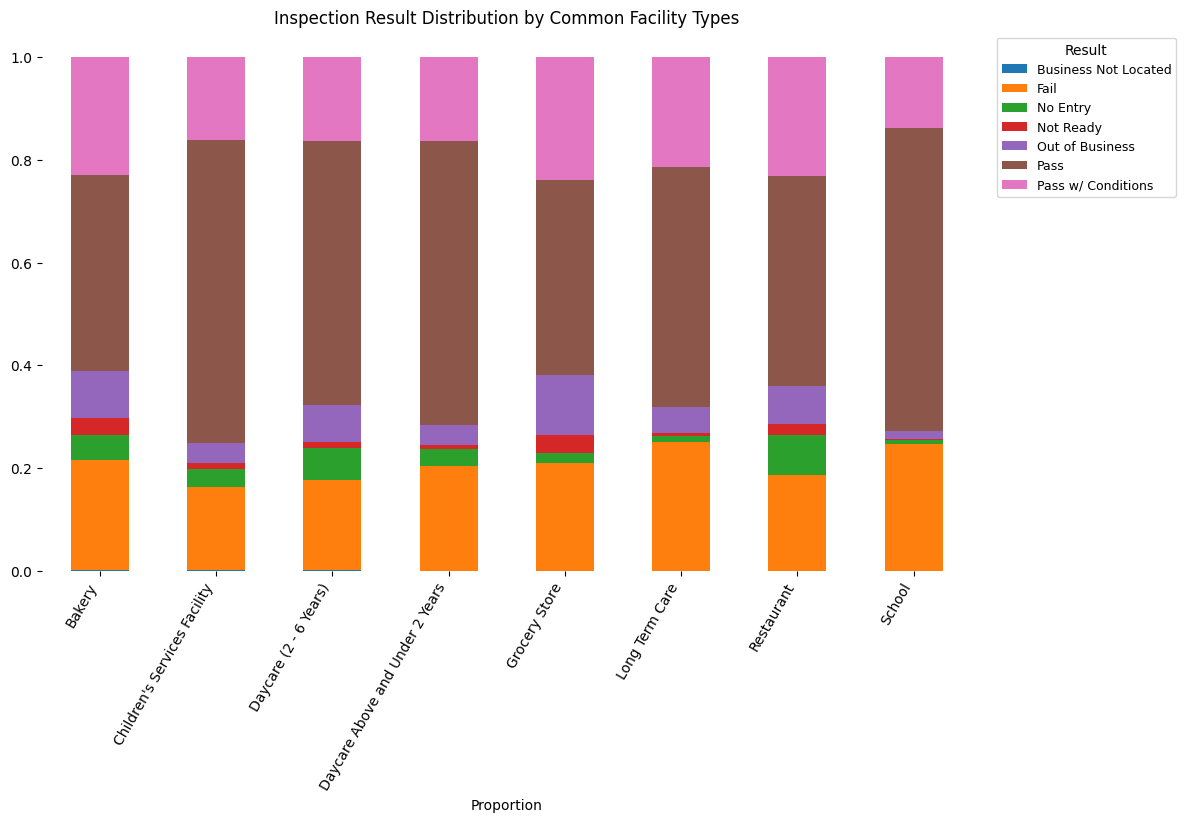

In [37]:
top_facilities = food['Facility Type'].value_counts().head(8).index
top_fac_df = food[food['Facility Type'].isin(top_facilities)]

ct_pct = pd.crosstab(
    top_fac_df['Facility Type'],
    top_fac_df['Results'],
    normalize='index'
)

ct_pct.plot(kind='bar', stacked=True, figsize=(12,7))
plt.title('Inspection Result Distribution by Common Facility Types')
plt.xlabel('Proportion')
plt.ylabel('')
plt.xticks(rotation=60, ha='right')
plt.legend(title='Result',
           bbox_to_anchor=(1.02, 1),
           loc='upper left', fontsize=9, title_fontsize=10)

sns.despine(left=True, bottom=True);


### Fail Rate Distribution Among Common Facility Types

Text(0, 0.5, '')

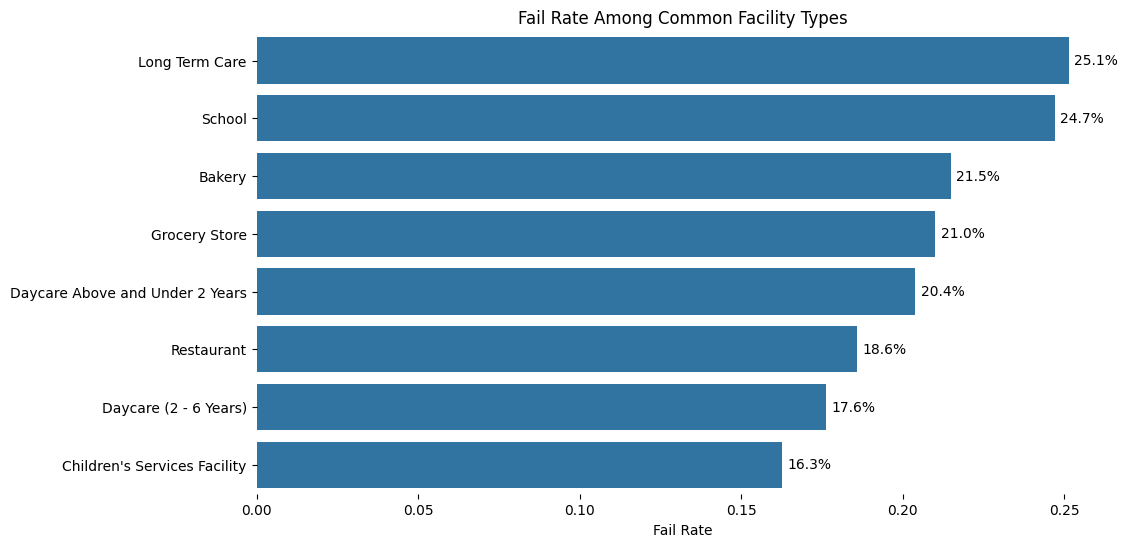

In [38]:
from matplotlib.ticker import PercentFormatter
fail_rates = (
    food[food['Facility Type'].isin(top_facilities)]
    .groupby(['Facility Type', 'Results'])
    .size()
    .unstack(fill_value=0)
)

fail_rates['Fail_Rate'] = fail_rates['Fail'] / fail_rates.sum(axis=1)

fail_rates_sorted = fail_rates.sort_values('Fail_Rate', ascending=False)

plt.figure(figsize=(11,6))
ax = sns.barplot(
    x=fail_rates_sorted['Fail_Rate'],
    y=fail_rates_sorted.index
)

for container in ax.containers:
    labels = [f'{v:.1%}' for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=4)

sns.despine(left=True, bottom=True)
plt.title('Fail Rate Among Common Facility Types')
plt.xlabel('Fail Rate')
plt.ylabel('')



Long-term Care facilities have the highest fail rate at ~25%, meaningfully above the citywide average of ~22.8%. Restaurants sit at ~18.5% — slightly below average despite comprising most inspections. This variation across facility types suggests `Facility Type` (grouped) is worth including as a modeling feature.

### Inspection Fail Rate by Month (aggregated)

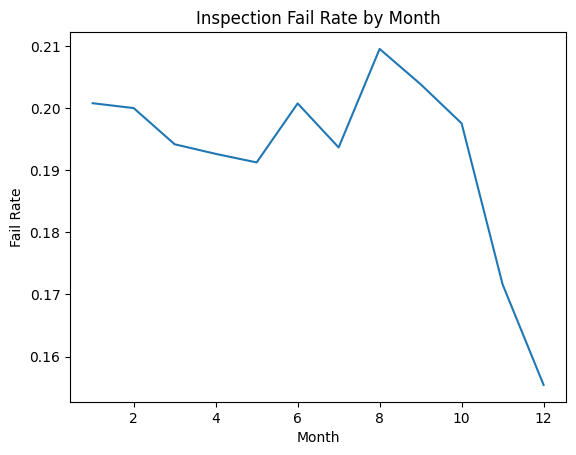

In [39]:
failratedf = (
    food_time_clean.groupby(food_time_clean['Inspection Date'].dt.month)['Fail']
    .mean()
    .reset_index()
)

ax = sns.lineplot(data = failratedf, x = 'Inspection Date', y = 'Fail')

ax.set_ylabel('Fail Rate')
plt.title('Inspection Fail Rate by Month')
ax.set_xlabel('Month');

Fail rates show a seasonal pattern, declining from ~20% in summer months to around 15% in the fall (September–December). This suggests `Inspection Month` may carry predictive signal and warrants inclusion as a temporal feature in the model.

### Inspection Fail Rate by Year (aggregated)

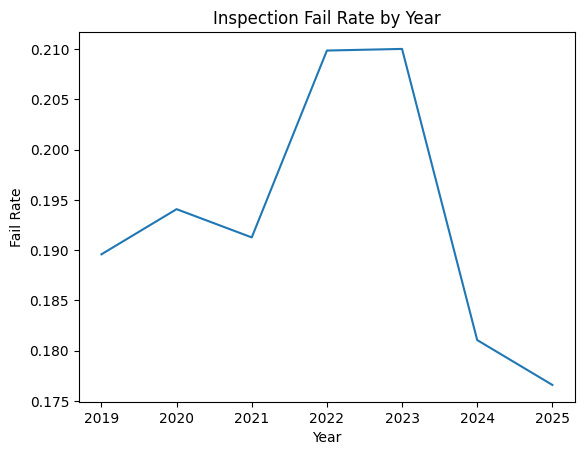

In [40]:
failratedf2 = (
    food_time_clean.groupby(food_time_clean['Inspection Date'].dt.year)['Fail']
    .mean()
    .reset_index()
)

ax = sns.lineplot(data = failratedf2, x = 'Inspection Date', y = 'Fail')

ax.set_ylabel('Fail Rate')
plt.title('Inspection Fail Rate by Year')
ax.set_xlabel('Year');

Fail rates are broadly stable year-over-year, ranging from 17.6% to 21%. There is no strong secular trend in either direction. `Inspection Year` will be included in the model primarily to allow it to capture any subtle drift, but it is not expected to be a top predictor.

### Inspection Result Distribution

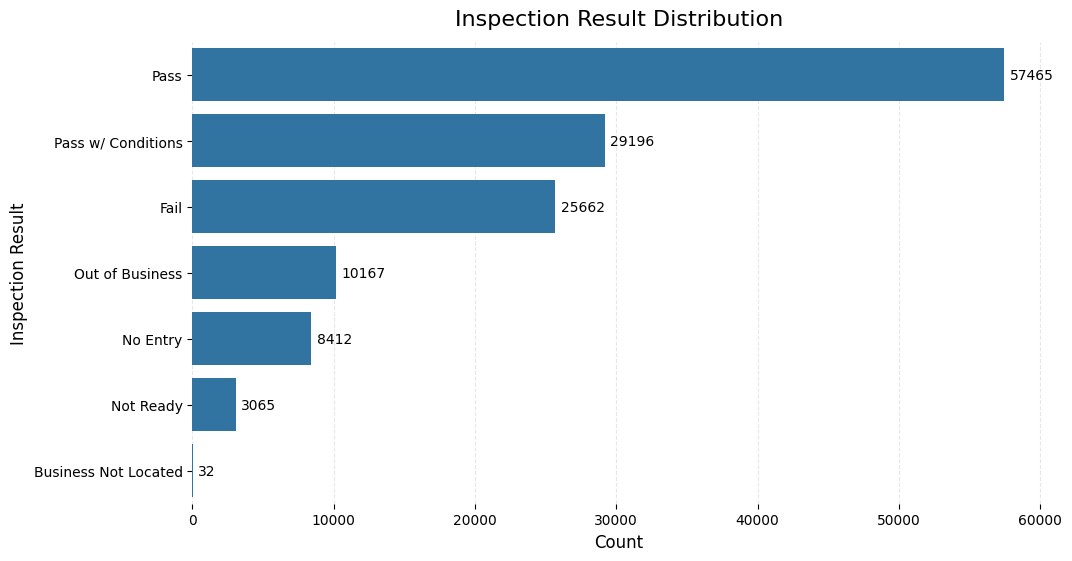

In [42]:
plt.figure(figsize=(11, 6))

order = food['Results'].value_counts().index
ax = sns.countplot(data=food, y='Results', order=order)

plt.title('Inspection Result Distribution', pad=12, fontsize=16)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Inspection Result', fontsize=12)
sns.despine(left=True, bottom=True)
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=4)



### Inspection Result by Inspection Type

<Figure size 1200x600 with 0 Axes>

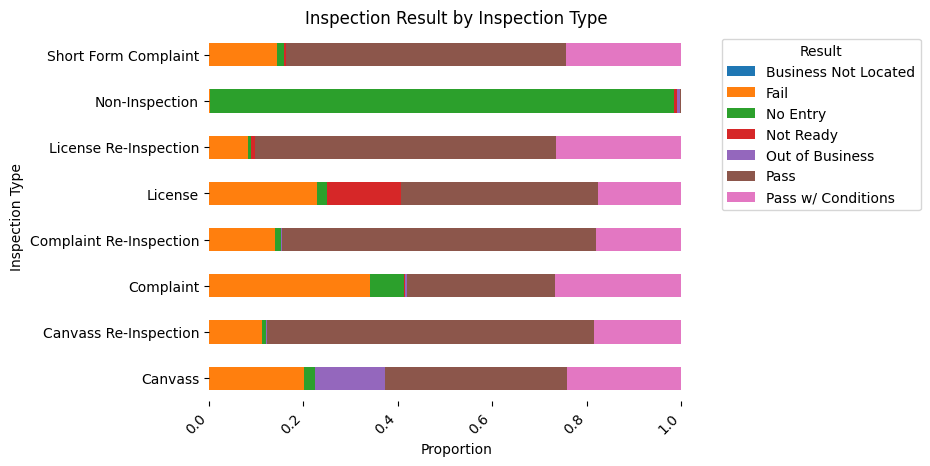

In [43]:
top_inspection = food['Inspection Type'].value_counts().head(8).index
top_df = food[food['Inspection Type'].isin(top_inspection)]

ct_pct = pd.crosstab(
    top_df['Inspection Type'],
    top_df['Results'],
    normalize='index'
)
plt.figure(figsize=(12,6))
ax = ct_pct.plot(kind='barh', stacked=True)
plt.title('Inspection Result by Inspection Type')
plt.ylabel('Inspection Type')
plt.xlabel('Proportion')
plt.xticks(rotation=45, ha='right');
plt.legend(title='Result', bbox_to_anchor=(1.02, 1), loc='upper left');
sns.despine(left=True, bottom=True)

Complaint-driven inspections show materially worse outcome distributions compared to routine canvass and license inspections — a logical finding, as complaints are typically triggered by observed problems. `Inspection Type` will be included as a feature in the model.

In [44]:
#inspection type distribution
topinsptype = food['Inspection Type'].value_counts().sort_values(ascending = False).head(10)
topinsptype



,count
Inspection Type,
Canvass,67420
License,18766
Canvass Re-Inspection,16244
Complaint,12759
Complaint Re-Inspection,5488
Non-Inspection,5245
License Re-Inspection,4635
Short Form Complaint,2823
Recent Inspection,285


Canvass inspections constitute the majority of overall inspections. This baseline distribution is important context when interpreting model performance, as the model will predominantly be evaluated on canvass-type records.

### Fail Rate: First-Time vs. Repeat Inspections

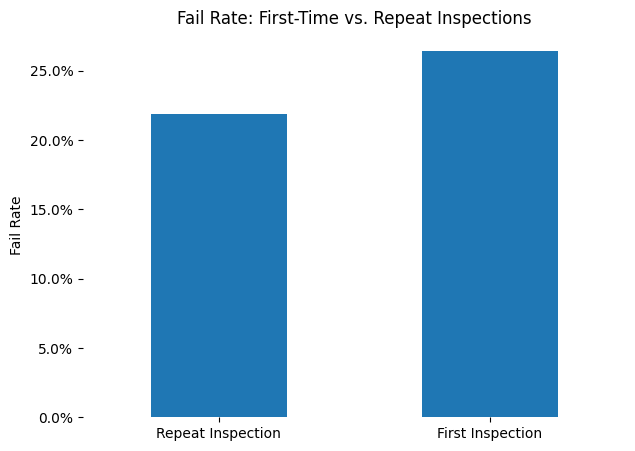

In [107]:
license_df = model_eligible.copy()
license_df = license_df.dropna(subset=['License #'])
license_df = license_df[license_df['License #'] != 0]
license_df = license_df.sort_values(['License #', 'Inspection Date'])
license_df['prior_inspections'] = license_df.groupby('License #').cumcount()
license_df['is_first'] = license_df['prior_inspections'] == 0

first_vs_repeat = (
    license_df.groupby('is_first')['Fail']
    .mean()
    .rename({True: 'First Inspection', False: 'Repeat Inspection'})
)

first_vs_repeat.plot(kind='bar', figsize=(7,5))
plt.title('Fail Rate: First-Time vs. Repeat Inspections')
plt.xlabel('')
plt.ylabel('Fail Rate')
plt.xticks(rotation=0)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
sns.despine(left=True, bottom=True)


Repeat inspections have a fail rate of **~21.8%**, around ~4.6% lower than first inspection fail rates (**26.4%**). This suggests that newer facilities or those that are earlier in their inspection history carry higher risk of failure, possibly attributed to less established food safety practices. These will be included as predictive features in the modeling section labeled as `prior_inspections` and `prior_fail_rate`.

### Result Distribution by Risk Category

In [ ]:
#result distribution by risk category
pd.crosstab(food['Results'], food['Risk']).transpose()

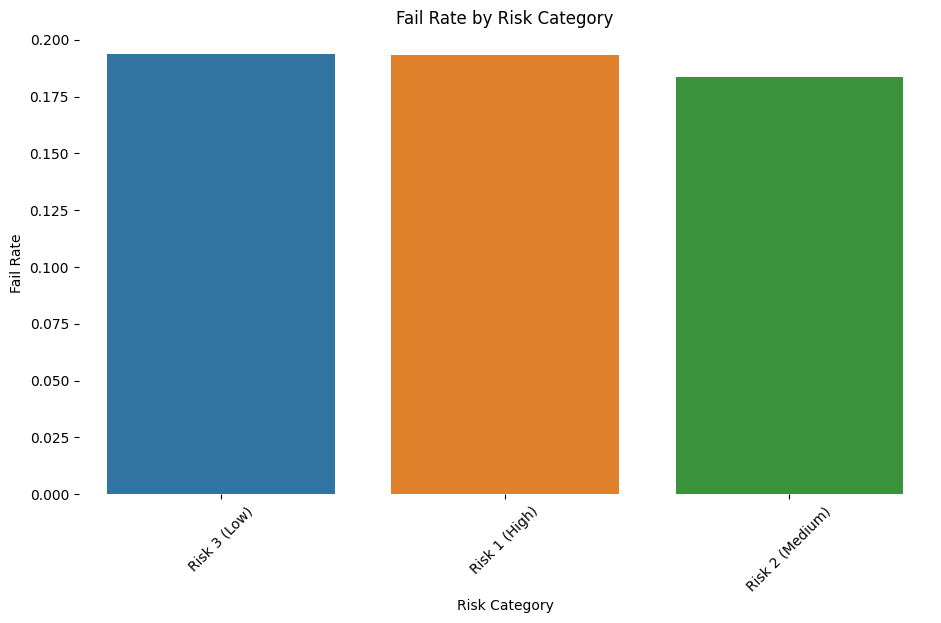

In [46]:
plt.figure(figsize = (11,6))
riskcatfailrate = (
    food[food['Risk'] != 'All']
    .groupby('Risk')
    .agg({'Fail': 'mean'})
    .sort_values(by='Fail', ascending=False)
    .reset_index()
)
order3 = riskcatfailrate['Risk']


ax = sns.barplot(data = riskcatfailrate, x = 'Risk', y = 'Fail', order = order3, hue = 'Risk')
plt.xticks(rotation = 45)
plt.title('Fail Rate by Risk Category')
ax.set_xlabel('Risk Category')
ax.set_ylabel('Fail Rate')
sns.despine(left = True, bottom = True)

In [ ]:
food['Risk'].value_counts()

Fail rates are relatively flat across the city's three risk tiers (High / Medium / Low), with only marginal differences between categories. This is a notable finding — the city's own risk classification does not appear well-calibrated to actual failure outcomes but more-so to inspection frequency. Because risk category shows little discriminating power in the raw data, it will be excluded from the modeling feature set.

### Result Distribution by Year

In [ ]:
pd.crosstab(food['Results'], food['Inspection Date'].dt.year).transpose()

### Fail Rate by Zip Code

In [ ]:
zip_df = food.dropna(subset=['Zip']).copy()

zip_df['Zip'] = zip_df['Zip'].astype(int).astype(str)

zip_summary = (
    zip_df.groupby('Zip')
    .agg(
        inspection_count=('Fail', 'size'),
        fail_rate=('Fail', 'mean')
    )
    .reset_index()
)

zip_summary.sort_values(by = 'fail_rate', ascending = False)

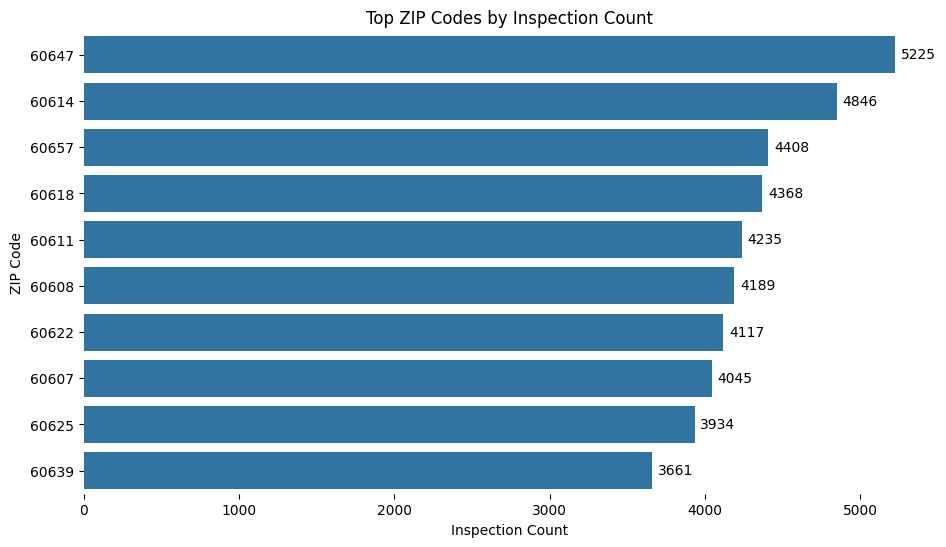

In [50]:
top_zip_counts = (
    zip_summary
    .sort_values('inspection_count', ascending=False)
    .head(10)
)

plt.figure(figsize=(11,6))
ax = sns.barplot(
    data=top_zip_counts,
    x='inspection_count',
    y='Zip'
)

plt.title('Top ZIP Codes by Inspection Count')
plt.xlabel('Inspection Count')
plt.ylabel('ZIP Code')
sns.despine(left=True, bottom=True)
ax.set_axisbelow(True)

for container in ax.containers:
    ax.bar_label(container, padding=4)




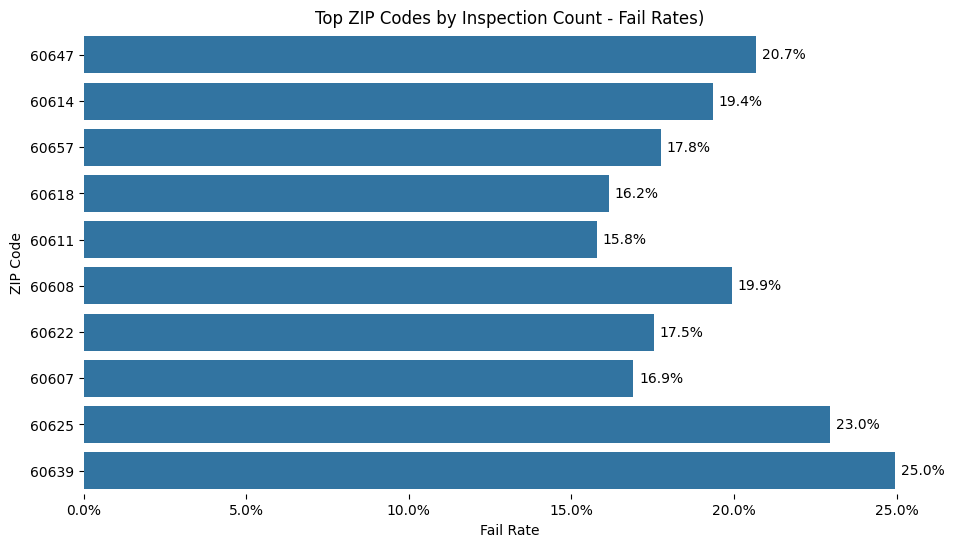

In [77]:
plt.figure(figsize=(11,6))
ax = sns.barplot(
    data=top_zip_counts,
    x='fail_rate',
    y='Zip'
)

plt.title('Top ZIP Codes by Inspection Count - Fail Rates)')
plt.xlabel('Fail Rate')
plt.ylabel('ZIP Code')
ax.xaxis.set_major_formatter(PercentFormatter(1.0))

sns.despine(left=True, bottom=True)
ax.set_axisbelow(True)

for container in ax.containers:
    labels = [f'{v:.1%}' for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=4)



In [78]:
zip_fail_filtered = zip_summary[zip_summary['inspection_count'] >=250].copy()

top_zip_fail = (
    zip_fail_filtered
    .sort_values('fail_rate', ascending=False)
    .head(10)
)

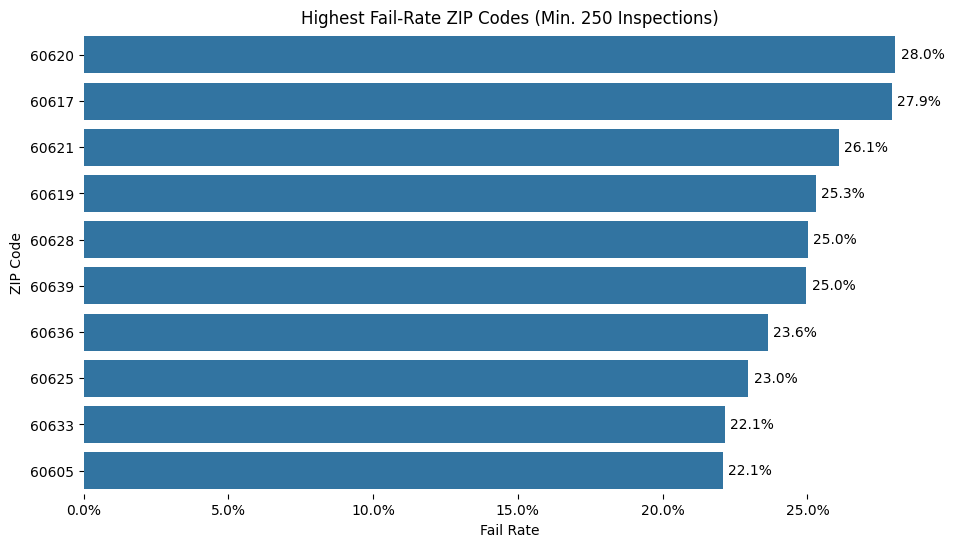

In [79]:
plt.figure(figsize=(11,6))
ax = sns.barplot(
    data=top_zip_fail,
    x='fail_rate',
    y='Zip'
)

plt.title('Highest Fail-Rate ZIP Codes (Min. 250 Inspections)')
plt.xlabel('Fail Rate')
plt.ylabel('ZIP Code')
ax.xaxis.set_major_formatter(PercentFormatter(1.0))

sns.despine(left=True, bottom=True)
ax.set_axisbelow(True)

for container in ax.containers:
    labels = [f'{v:.1%}' for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=4)



In [ ]:
zip_fail_filtered.sort_values(by = 'fail_rate', ascending = False).head(10)

The highest-volume ZIPs (**60647**, **60614**) show fail rates close to the citywide average of **~22.8%.** The highest fail-rate ZIPs **(60620** at **28%**, **60617** and **27.9%**) are geographically distinct, concentrated on the South and West sides of Chicago (not just artifacts of high inspection volume). **60625** and **60639** appear in both inspection count and fail rate lists, making them the most concerning ZIPs due to their high inspection demand and elevated failure rates. ZIP code will be included in the modeling process as a predictive feature.




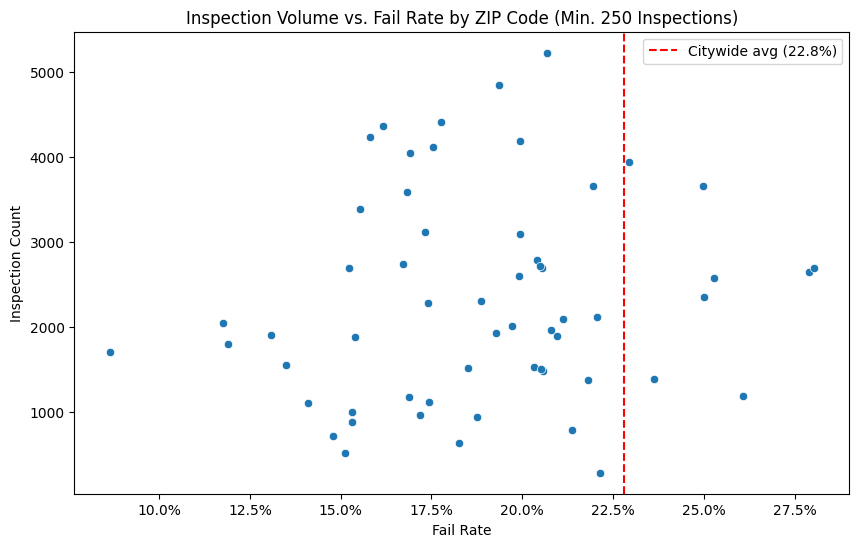

In [111]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=zip_fail_filtered, x='fail_rate', y='inspection_count')
plt.axvline(x=0.228, color='red', linestyle='--', label='Citywide avg (22.8%)')
plt.title('Inspection Volume vs. Fail Rate by ZIP Code (Min. 250 Inspections)')
plt.xlabel('Fail Rate')
plt.ylabel('Inspection Count')
plt.gca().xaxis.set_major_formatter(PercentFormatter(1.0))
plt.legend()

A scatterplot between inspection count and fail rate shows no meaningful relationship - in that high volume ZIPs are not systematically higher or lower risk than low-volume ones. The ZIP observations to the right of the citywide average (**22.8%**) are the majority of ZIPs that warrant further investigation.

---

## EDA Summary & Modeling Implications

| Finding | Modeling Implication |
|---|---|
| Inspection volume dipped 2020–2022 (COVID) | Include `Inspection Year` as a temporal control |
| Fail rates vary meaningfully by facility type | Include grouped `Facility Type` as a feature |
| Seasonal pattern in fail rates (lower in fall) | Include `Inspection Month` as a feature |
| Complaint inspections fail at higher rates | Include `Inspection Type` as a feature |
| Risk category shows flat fail rates across tiers | **Exclude** — low discriminating power |
| ZIP codes show significant fail rate variation | Include `Zip` as a feature; apply minimum inspection threshold |
| Fail rates stable year-over-year (~17–21%) | Class imbalance (~22.8% fail) warrants `class_weight='balanced'` in modeling |



## Limitations

- **Violations field** - the `Violations` column contains free-text descriptions of each specific violation. Due to its unstructured format as well as a meaningful amount of null values (~39k), it was excluded from the analysis.

- **ZIP findings** - an inspection count volume threshold of 250 was implemented as fail rate outliers containing small sample sizes were detected

- **Risk classification findings** - Risk classification seems to be a determinant on how *often* a facility is inspected, instead of a measure of actual failure likelihood. Due to this, it won't be included as a feature during modeling.

